In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


this is our best model till now , let me show the results

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8650 - loss: 0.6131 - val_accuracy: 0.9669 - val_loss: 0.4293
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9774 - loss: 0.1879 - val_accuracy: 0.9711 - val_loss: 0.2968
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9729 - loss: 0.1521 - val_accuracy: 0.9752 - val_loss: 0.2186
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9791 - loss: 0.1305 - val_accuracy: 0.9752 - val_loss: 0.1675
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9857 - loss: 0.1154 - val_accuracy: 0.9711 - val_loss: 0.1440
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9878 - loss: 0.0907 - val_accuracy: 0.9752 - val_loss: 0.1250
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9832 - loss: 0.0966 - val_accuracy: 0.9793 - val_loss: 0.1174
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9889 - loss: 0.0842 - val_accuracy: 0.9752 - val_lo

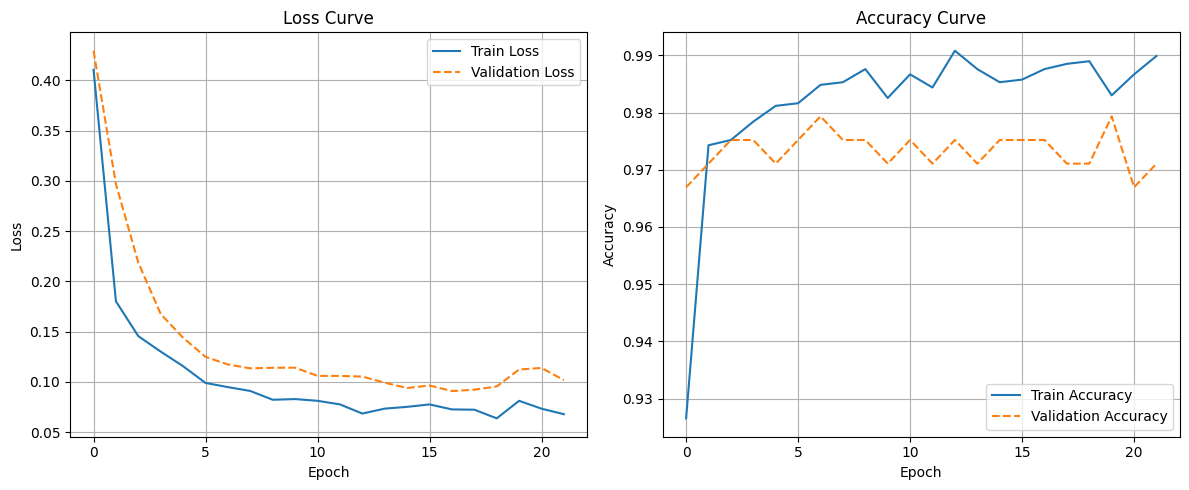

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41, stratify=y
)

# Step 5: Define the MLP model
model4 = Sequential([
    Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False),  # Hidden layer
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),  # Dropout layer (50% dropout rate)
    Dense(1, activation='sigmoid',kernel_regularizer=l2(0.001))                      # Output layer
])

# Step 6: Compile the model4
optimizer = Adam(learning_rate=0.001)
model4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        
# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)              

# Step 8: Train the model4
history = model4.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model4.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model4
# model2.save("botnet_original_arch_dropout.h5")
# print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



now we will apply keras tuner to get the best optimizer for this model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(454, input_shape=(455,),kernel_regularizer=l2(0.001), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3
)

# Start tuning
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Trial 3 Complete [00h 00m 22s]
val_accuracy: 0.9816955924034119

Best val_accuracy So Far: 0.9826589822769165
Total elapsed time: 00h 01m 28s


In [ ]:
import shutil
shutil.rmtree('untitled_project')

adam is giving 98.26 % accuracy

In [ ]:
tuner.get_best_hyperparameters()[0].values
model = tuner.get_best_models()[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 454)            │       206,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 454)            │         1,816 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 454)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 454)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,841 (815.79 KB)

 Trainable params: 207,933 (812.24 KB)

 Non-trainable params: 908 (3.55 KB)

In [ ]:
#now will check the number of neurons in the hidden layer + optimizer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units', min_value=32, max_value=448), input_shape=(455,), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    optimizer = hp.Choice('optimizer', values=['adam'])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=False
)

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=100
)

# Start tuning
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Trial 100 Complete [00h 00m 14s]
val_accuracy: 0.9797688126564026

Best val_accuracy So Far: 0.9836223721504211
Total elapsed time: 00h 26m 14s


In [11]:
tuner.get_best_hyperparameters()[0].values


{'units': 441, 'optimizer': 'adam'}